## Feature Scaling

#### **피처 스케일링(Feature Scaling)** 이란 서로 다른 범위(단위)를 가진 피처들을 **일정한 기준으로 맞춰주는** 전처리 과정이다.

#### 왜 스케일링이 필요한가?
- **공정한 학습**: 피처 간 크기 차이로 인한 편향을 제거하여 모든 피처가 동등하게 반영되도록 한다.
- **수렴 속도 향상**: 모델 학습시 빠르고 안정적으로 최적값에 수렴한다.
- **거리 계산 정확도**: k-NN, KMeans 등 거리 기반 알고리즘에서 특정 피처에 치우치지 않는 올바른 거리 측정이 가능하다.

| 구분 | Standard Scaler | MinMax Scaler | Robust Scaler | Normalizer |
|---|---|---|---|---|
| **기준** | 평균=0, 분산=1 | 최솟값=0, 최댓값=1 | 중앙값=0, IQR 기준 | 행(샘플)의 L2 norm=1 |
| **스케일링 축** | 열(피처) 기준 | 열(피처) 기준 | 열(피처) 기준 | **행(샘플) 기준** |
| **이상치 민감도** | 높음 | 높음 | **낮음** (IQR 사용) | 낮음 |
| **적합 상황** | 정규분포에 가까운 데이터 | 범위가 고정된 입력이 필요할 때 | 이상치가 많은 데이터 | 벡터 유사도 비교 (텍스트 등) |
| **적합 모델** | SVM, 로지스틱 회귀 | 신경망, k-NN | 이상치 포함 데이터 전반 | 문서 분류, 코사인 유사도 |
| **예시** | [1,2,3,4,5]→[-1.26,…,1.26] | [1,2,3,4,5]→[0,0.25,…,1] | [1,2,3,4,5]→[-1,…,1] | [[1,2],[2,3]]→[[0.45,0.89],…] |

![](https://velog.velcdn.com/images/newnew_daddy/post/c1012f8d-8a85-4e67-b4cf-b8a685507525/image.png)
![](https://velog.velcdn.com/images/newnew_daddy/post/ab0abca9-2dcd-4e8d-b790-d971e1b5b0c2/image.png)

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("./dataset/null.csv")

df.head()

,A,B,C
0,5.0,0.0,376.0
1,3.0,0.0,94.0
2,3.0,91.0,141.0
3,NaN,78.0,NaN
4,2.0,104.0,376.0


In [ ]:
# 결측치 처리
df = df.fillna(df.mean())

df.head()

,A,B,C
0,5.0,0.0,376.000000
1,3.0,0.0,94.000000
2,3.0,91.0,141.000000
3,3.4,78.0,228.869565
4,2.0,104.0,376.000000


KDE (커널밀도추정: Kernel Density Estimation) plot

- 구간별 분포 수를 표현해주는 히스토그램을 연속적인 선으로 나타낸 그래프
- 데이터가 특정 범위에 얼마나 집중되어 있는지를 표현하는 그래프
- 데이터의 연속적인 분포를 시각화하기에 적합하며 데이터의 패턴을 확인할 수 있다.

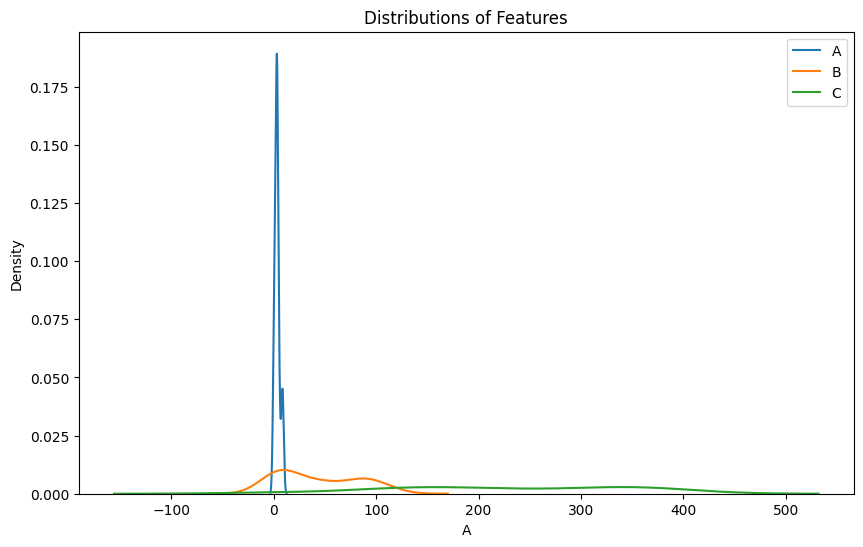

In [5]:
# 정규분포 시각화 (하나의 그래프에 선형 그래프만)
plt.figure(figsize=(10, 6))

for col in df.columns:
    sns.kdeplot(df[col], label=col)

plt.title('Distributions of Features')
plt.legend()
plt.show()

#### 1. Standard Scaler
- 평균이 0이고 분산이 1이 되도록 데이터의 각 특징을 스케일링합니다.
- 데이터가 정규분포를 따를 때 유용하며, SVM이나 로지스틱 회귀와 같은 모델에 적합합니다.
- 하한값과 상한값이 존재하지 않을 수 있기에, 어떤 알고리즘에서는 문제가 있을 수 있습니다. 
- [1, 2, 3, 4, 5] -> [-1.26, -0.63, 0, 0.63, 1.26]

In [6]:
from sklearn.preprocessing import StandardScaler

scaler_standard = StandardScaler()
df_standard = scaler_standard.fit_transform(df)

df_standard = pd.DataFrame(df_standard, columns=df.columns)

In [7]:
df_standard.describe()

,A,B,C
count,5.000000e+01,5.000000e+01,5.000000e+01
mean,-3.996803e-17,-7.993606e-17,2.220446e-16
std,1.010153e+00,1.010153e+00,1.010153e+00
min,-1.381612e+00,-1.117059e+00,-2.031748e+00
25%,-5.688989e-01,-7.780897e-01,-7.800461e-01
50%,-1.625425e-01,0.000000e+00,2.523086e-16
75%,4.876276e-01,9.167592e-01,8.888897e-01
max,2.275596e+00,1.933668e+00,1.306124e+00


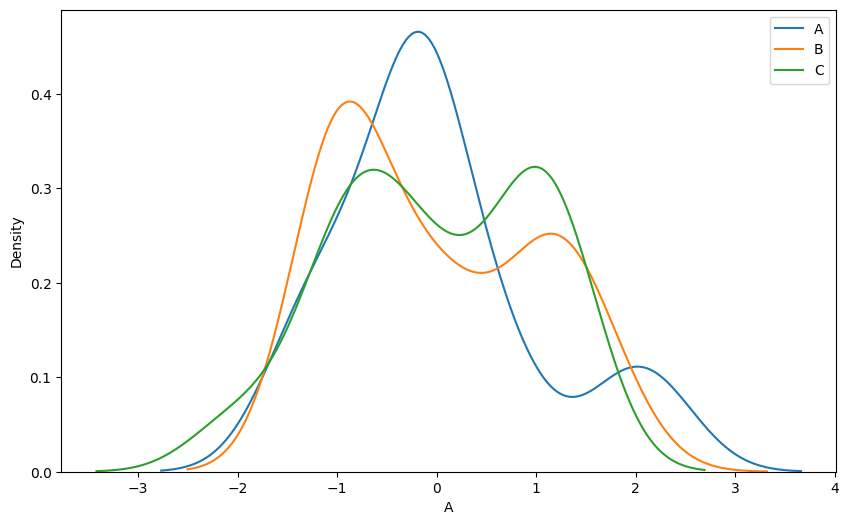

In [8]:
plt.figure(figsize=(10, 6))

for col in df_standard.columns:
    sns.kdeplot(df_standard[col], label=col)

plt.legend()
plt.show()

#### 2. MinMax Scaler
- 데이터의 각 특징을 최소값 0, 최대값 1로 변환합니다.
- 값의 범위가 고정되어 있어, 신경망이나 k-NN 모델에서 많이 사용됩니다.
- [1, 2, 3, 4, 5] -> [0, 0.25, 0.5, 0.75, 1]

In [9]:
from sklearn.preprocessing import MinMaxScaler

scaler_minmax = MinMaxScaler()
df_minmax = scaler_minmax.fit_transform(df)

df_minmax = pd.DataFrame(df_minmax, columns=df.columns)

In [10]:
df_minmax.describe()

,A,B,C
count,50.000000,50.000000,50.000000
mean,0.377778,0.366162,0.608696
std,0.276209,0.331119,0.302634
min,0.000000,0.000000,0.000000
25%,0.222222,0.111111,0.375000
50%,0.333333,0.366162,0.608696
75%,0.511111,0.666667,0.875000
max,1.000000,1.000000,1.000000


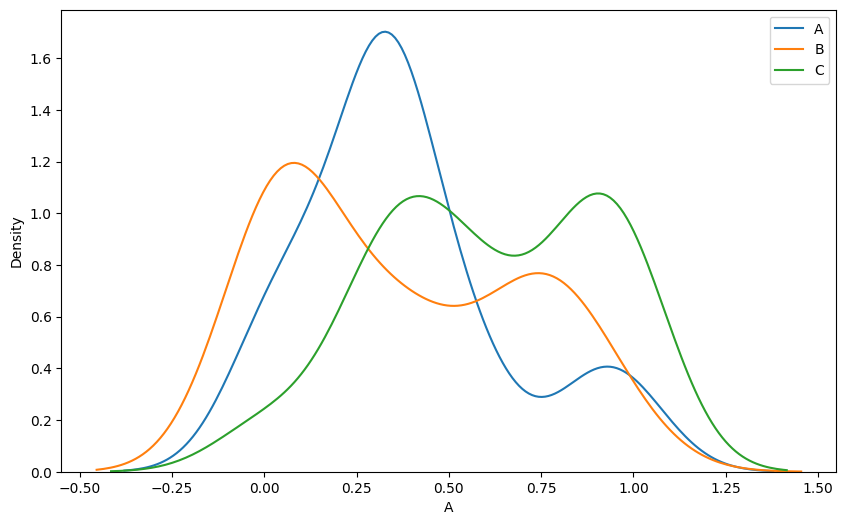

In [11]:
plt.figure(figsize=(10, 6))

for col in df_minmax.columns:
    sns.kdeplot(df_minmax[col], label=col)

plt.legend()
plt.show()

In [13]:
from sklearn.preprocessing import MaxAbsScaler

# 데이터의 각 특징을 최소값 -1, 최대값 1로 변환합니다.
scaler_maxabs = MaxAbsScaler()
df_maxabs = scaler_maxabs.fit_transform(df)

df_maxabs = pd.DataFrame(df_maxabs, columns=df.columns)

df_maxabs.describe()

,A,B,C
count,50.000000,50.000000,50.000000
mean,0.377778,0.366162,0.608696
std,0.276209,0.331119,0.302634
min,0.000000,0.000000,0.000000
25%,0.222222,0.111111,0.375000
50%,0.333333,0.366162,0.608696
75%,0.511111,0.666667,0.875000
max,1.000000,1.000000,1.000000


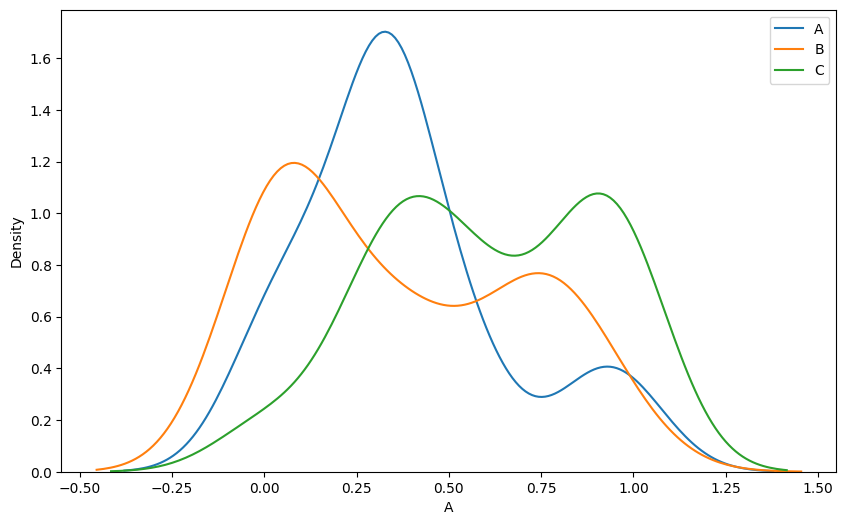

In [14]:
plt.figure(figsize=(10, 6))

for col in df_maxabs.columns:
    sns.kdeplot(df_maxabs[col], label=col)

plt.legend()
plt.show()

#### 3. Robust Scaler
- 중앙값(median)과 IQR(Interquartile Range)을 사용하여 스케일링하여 극단값(outliers)의 영향을 줄입니다.
- 데이터에 이상치가 많을 때 사용하면 효과적입니다. 이상치의 영향을 최소화
- [1, 2, 3, 4, 5] -> [-1, -0.5, 0, 0.5, 1]

In [15]:
from sklearn.preprocessing import RobustScaler

scaler_robust = RobustScaler()
df_robust = scaler_robust.fit_transform(df)

df_robust = pd.DataFrame(df_robust, columns=df.columns)

In [16]:
df_robust.describe()

,A,B,C
count,50.000000,5.000000e+01,5.000000e+01
mean,0.153846,-3.774758e-17,-6.550316e-17
std,0.956107,5.960133e-01,6.052675e-01
min,-1.153846,-6.590909e-01,-1.217391e+00
25%,-0.384615,-4.590909e-01,-4.673913e-01
50%,0.000000,0.000000e+00,0.000000e+00
75%,0.615385,5.409091e-01,5.326087e-01
max,2.307692,1.140909e+00,7.826087e-01


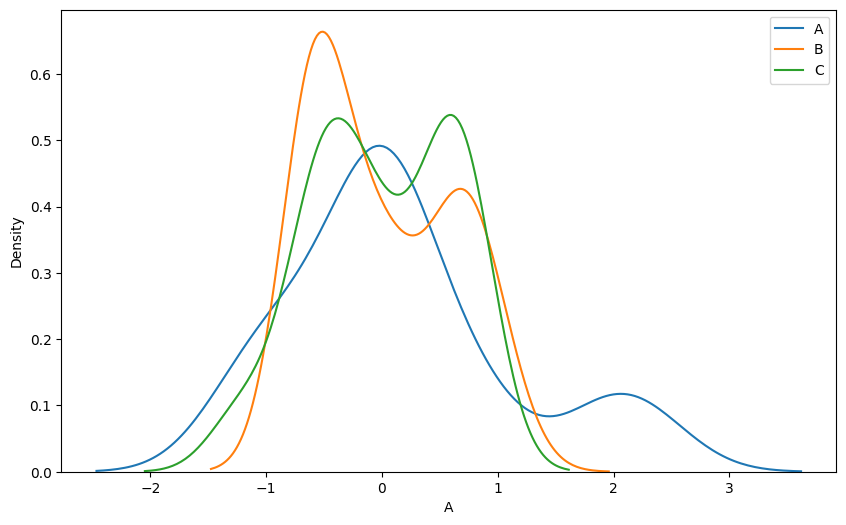

In [17]:
plt.figure(figsize=(10, 6))

for col in df_robust.columns:
    sns.kdeplot(df_robust[col], label=col)

plt.legend()
plt.show()

#### 4. Normalizer
- 각 **행(샘플)** 의 벡터 크기(L2 norm)가 1이 되도록 정규화 (앞의 스케일러들은 **열(특성)** 기준)
- 주로 문서 벡터, 유사도 비교 등에 사용되며, 단위가 다른 피처(키·나이·소득 등)에는 부적합
- [[1, 2], [2, 3]] → [[0.45, 0.89], [0.55, 0.83]]

In [18]:
from sklearn.preprocessing import Normalizer

scaler_normalizer = Normalizer()
df_normalizer = scaler_normalizer.fit_transform(df)

df_normalizer = pd.DataFrame(df_normalizer, columns=df.columns)

In [20]:
df_normalizer.head()

,A,B,C
0,0.013297,0.000000,0.999912
1,0.031899,0.000000,0.999491
2,0.017874,0.542176,0.840075
3,0.014060,0.322554,0.946447
4,0.005127,0.266583,0.963798


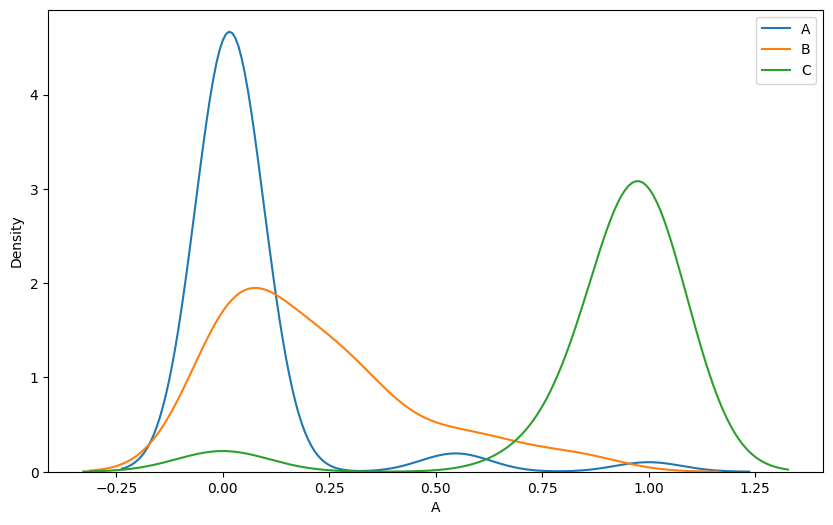

In [21]:
plt.figure(figsize=(10, 6))

for col in df_normalizer.columns:
    sns.kdeplot(df_normalizer[col], label=col)

plt.legend()
plt.show()

#### 5. 정규화 비교 시각화

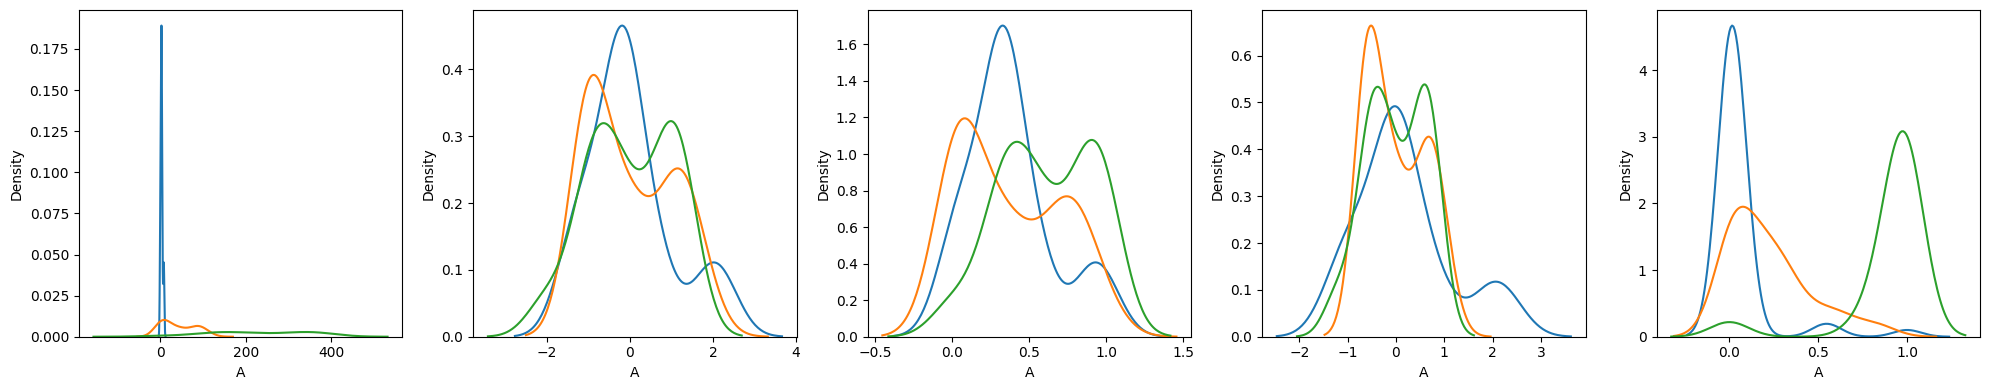

In [23]:
## plt.subplot(nrows, ncols, index)

plt.figure(figsize=(20, 4))

plt.subplot(1, 5, 1)
for col in df.columns:
    sns.kdeplot(df[col], label=col)

plt.subplot(1, 5, 2)
for col in df_standard.columns:
    sns.kdeplot(df_standard[col], label=col)

plt.subplot(1, 5, 3)
for col in df_minmax.columns:
    sns.kdeplot(df_minmax[col], label=col)

plt.subplot(1, 5, 4)
for col in df_robust.columns:
    sns.kdeplot(df_robust[col], label=col)

plt.subplot(1, 5, 5)
for col in df_normalizer.columns:
    sns.kdeplot(df_normalizer[col], label=col)

plt.tight_layout()
plt.show()
